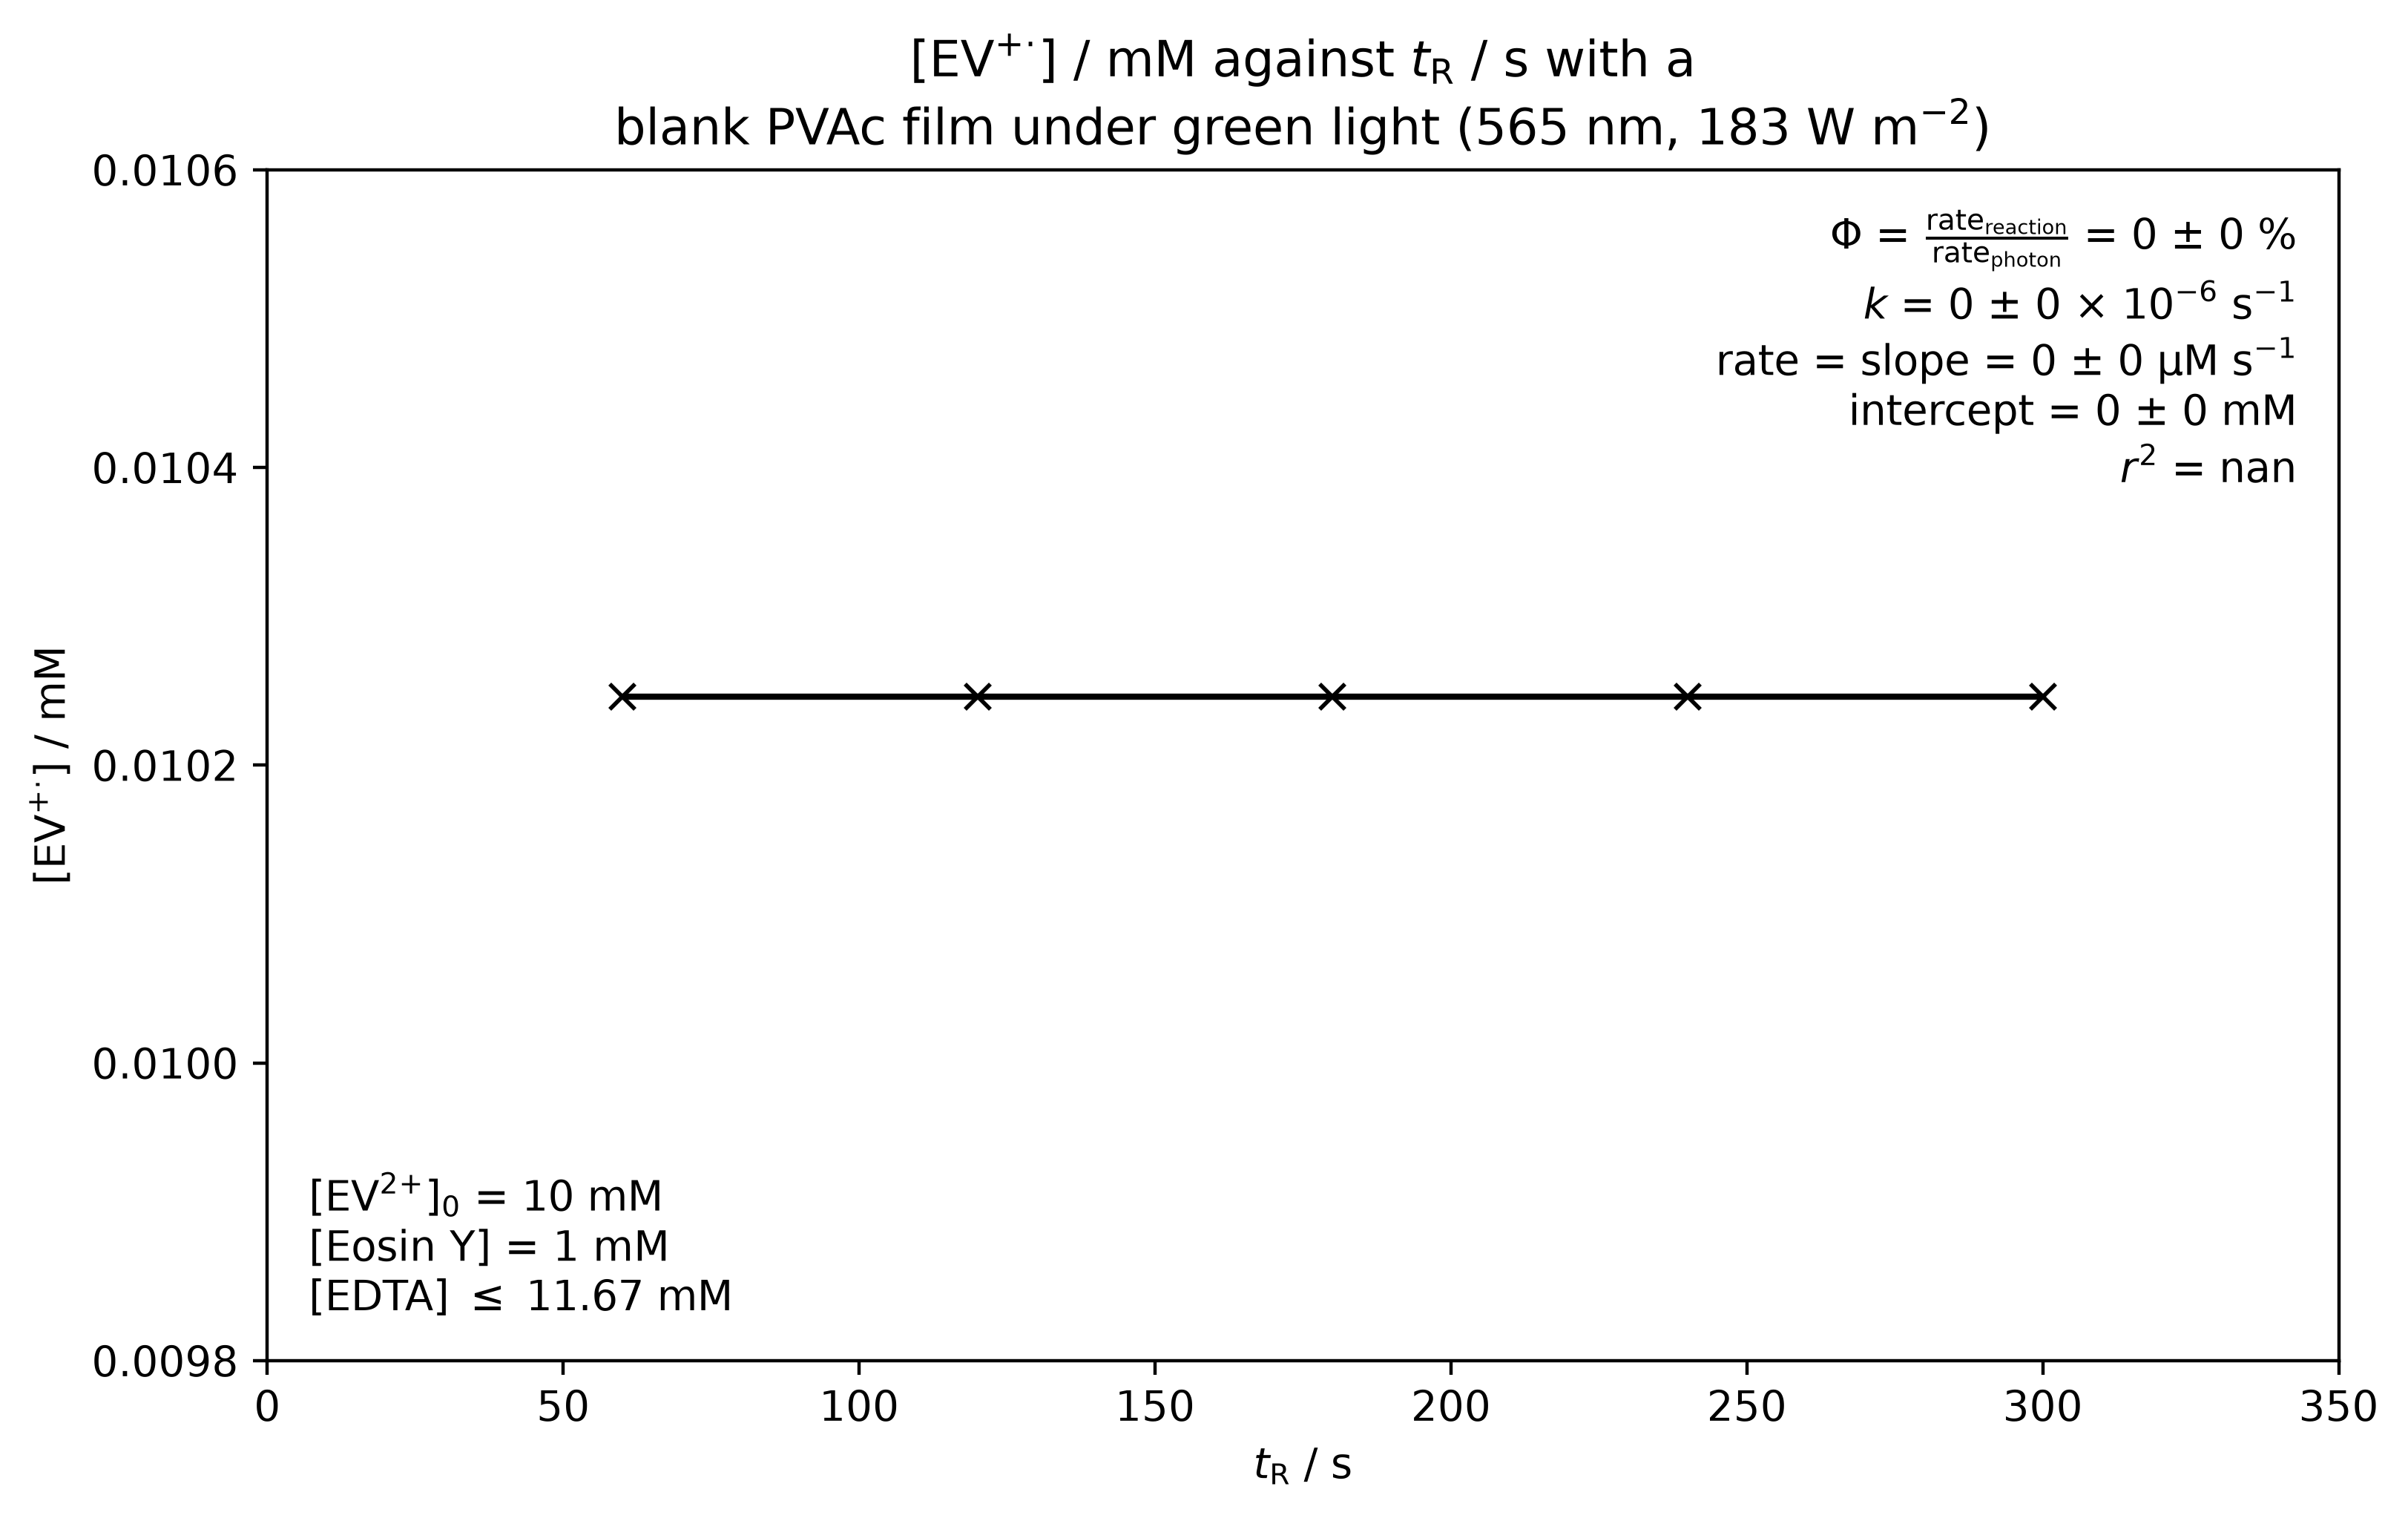

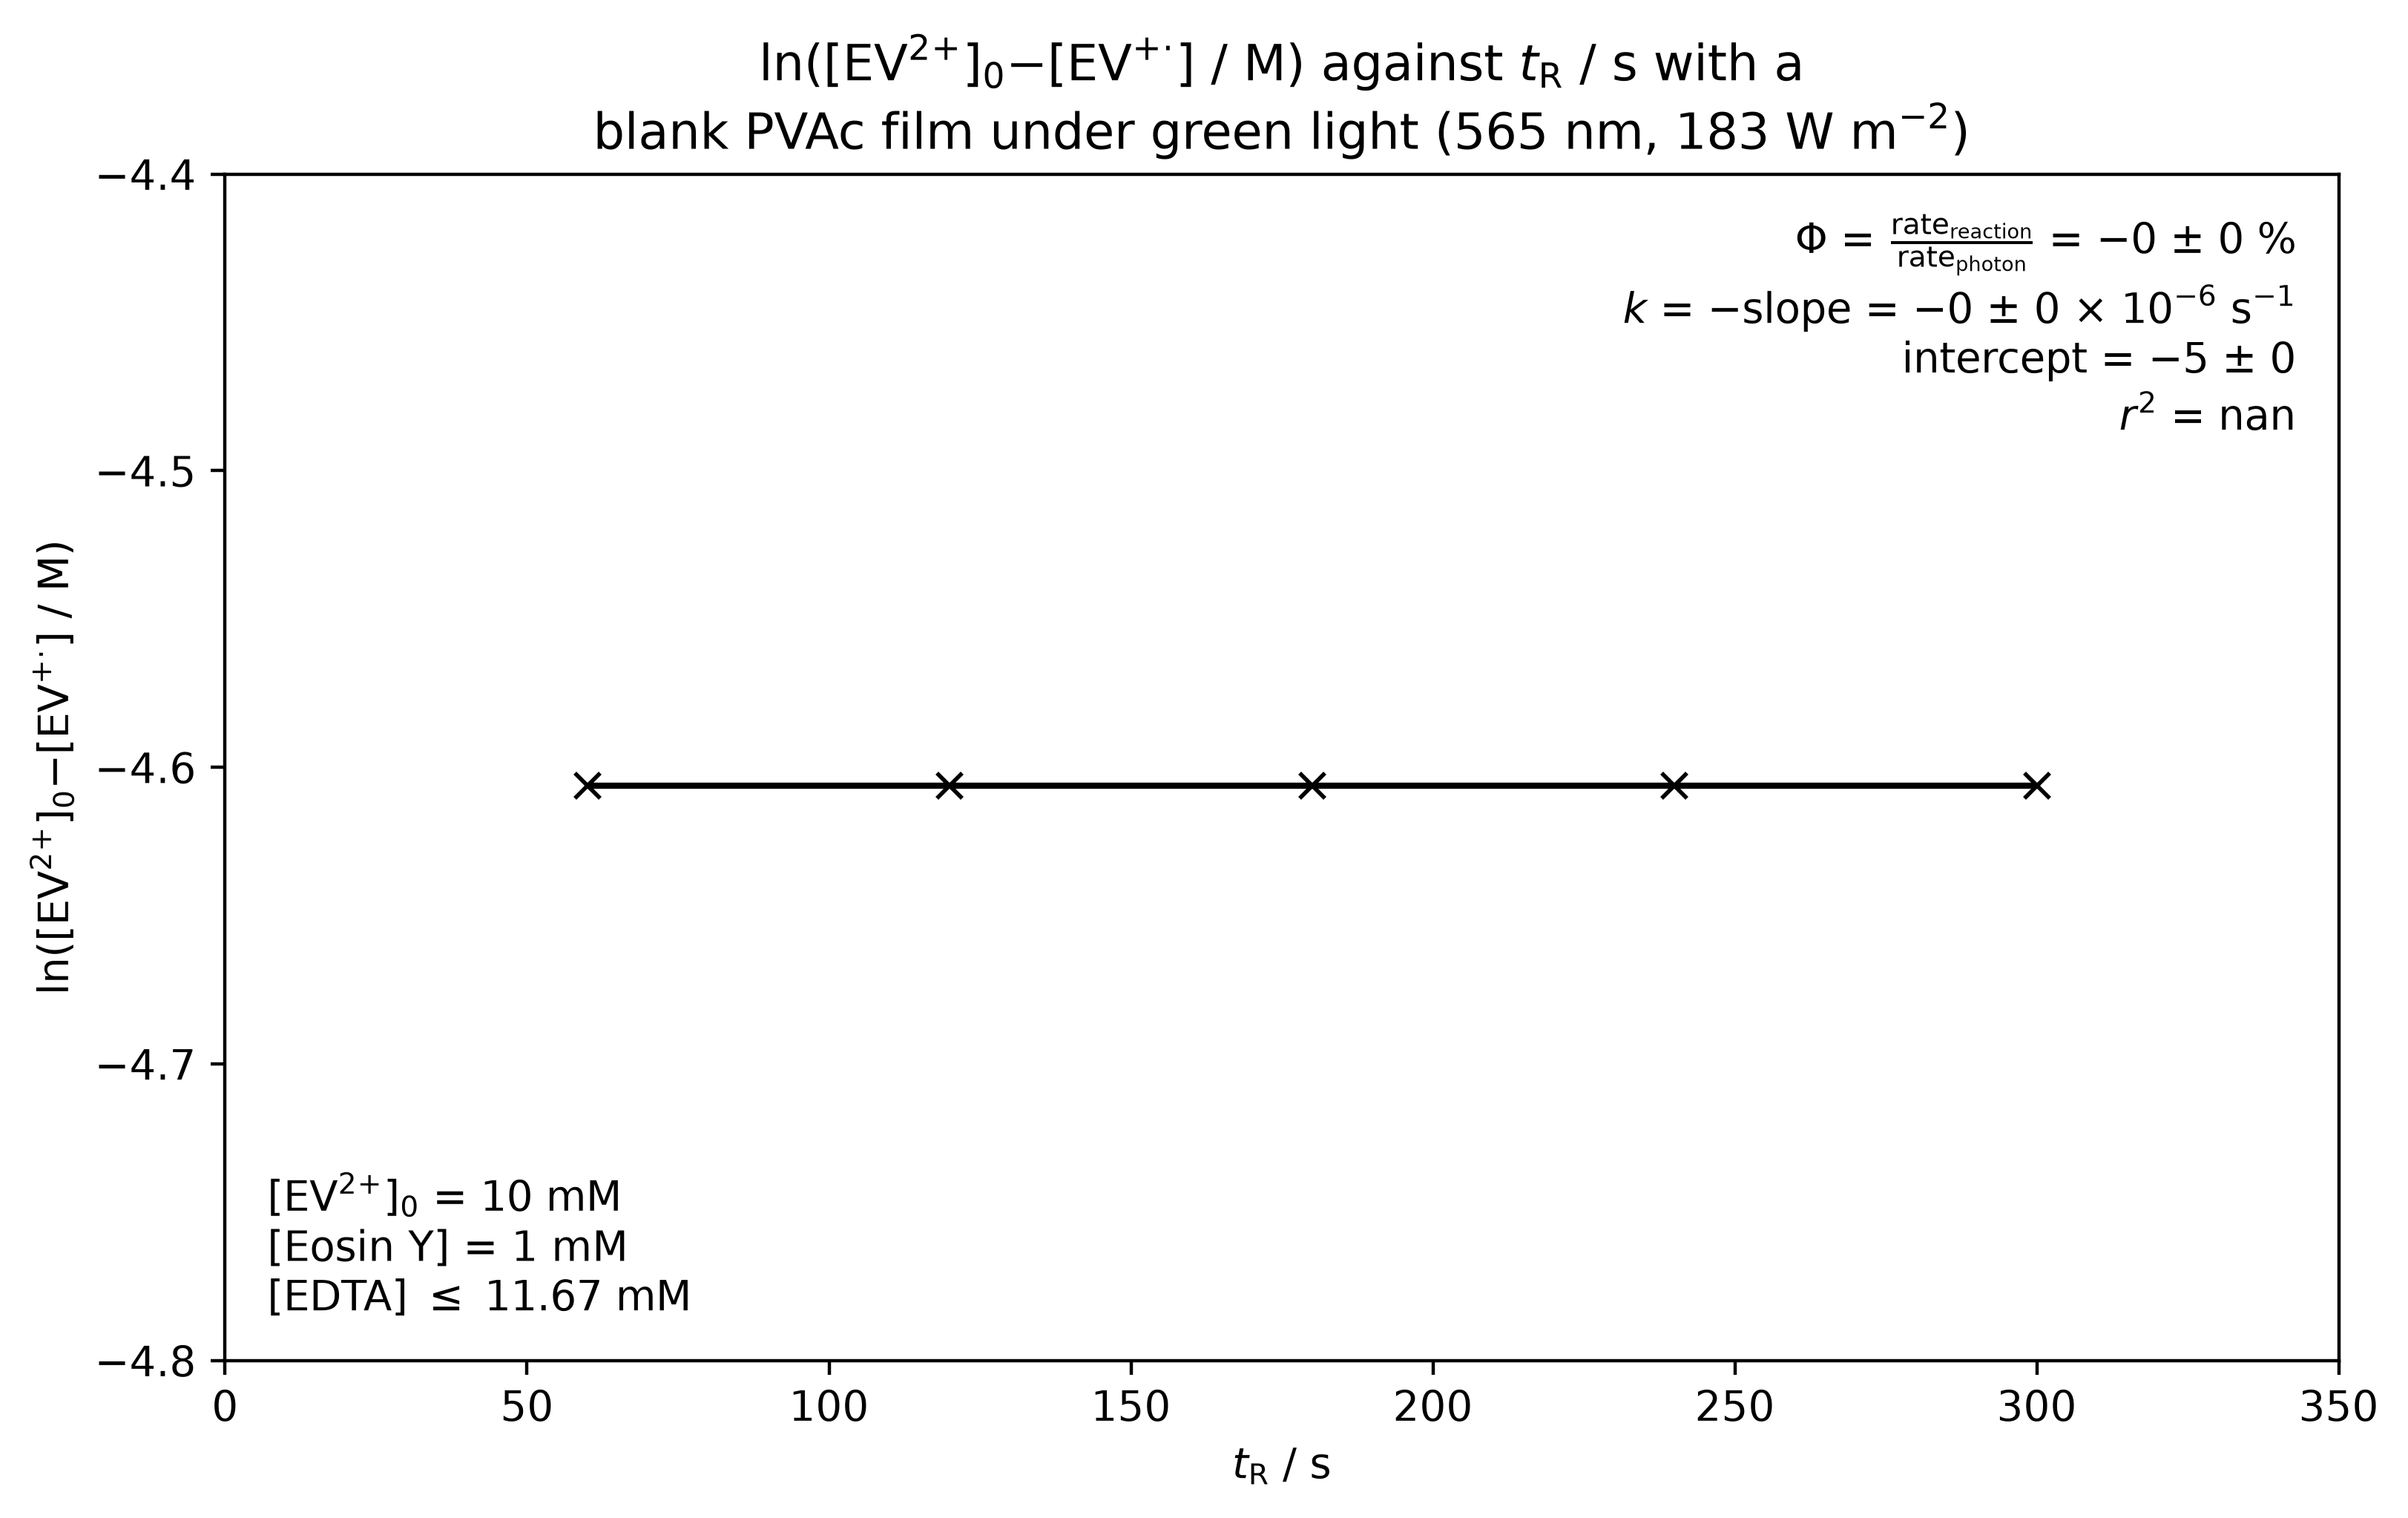

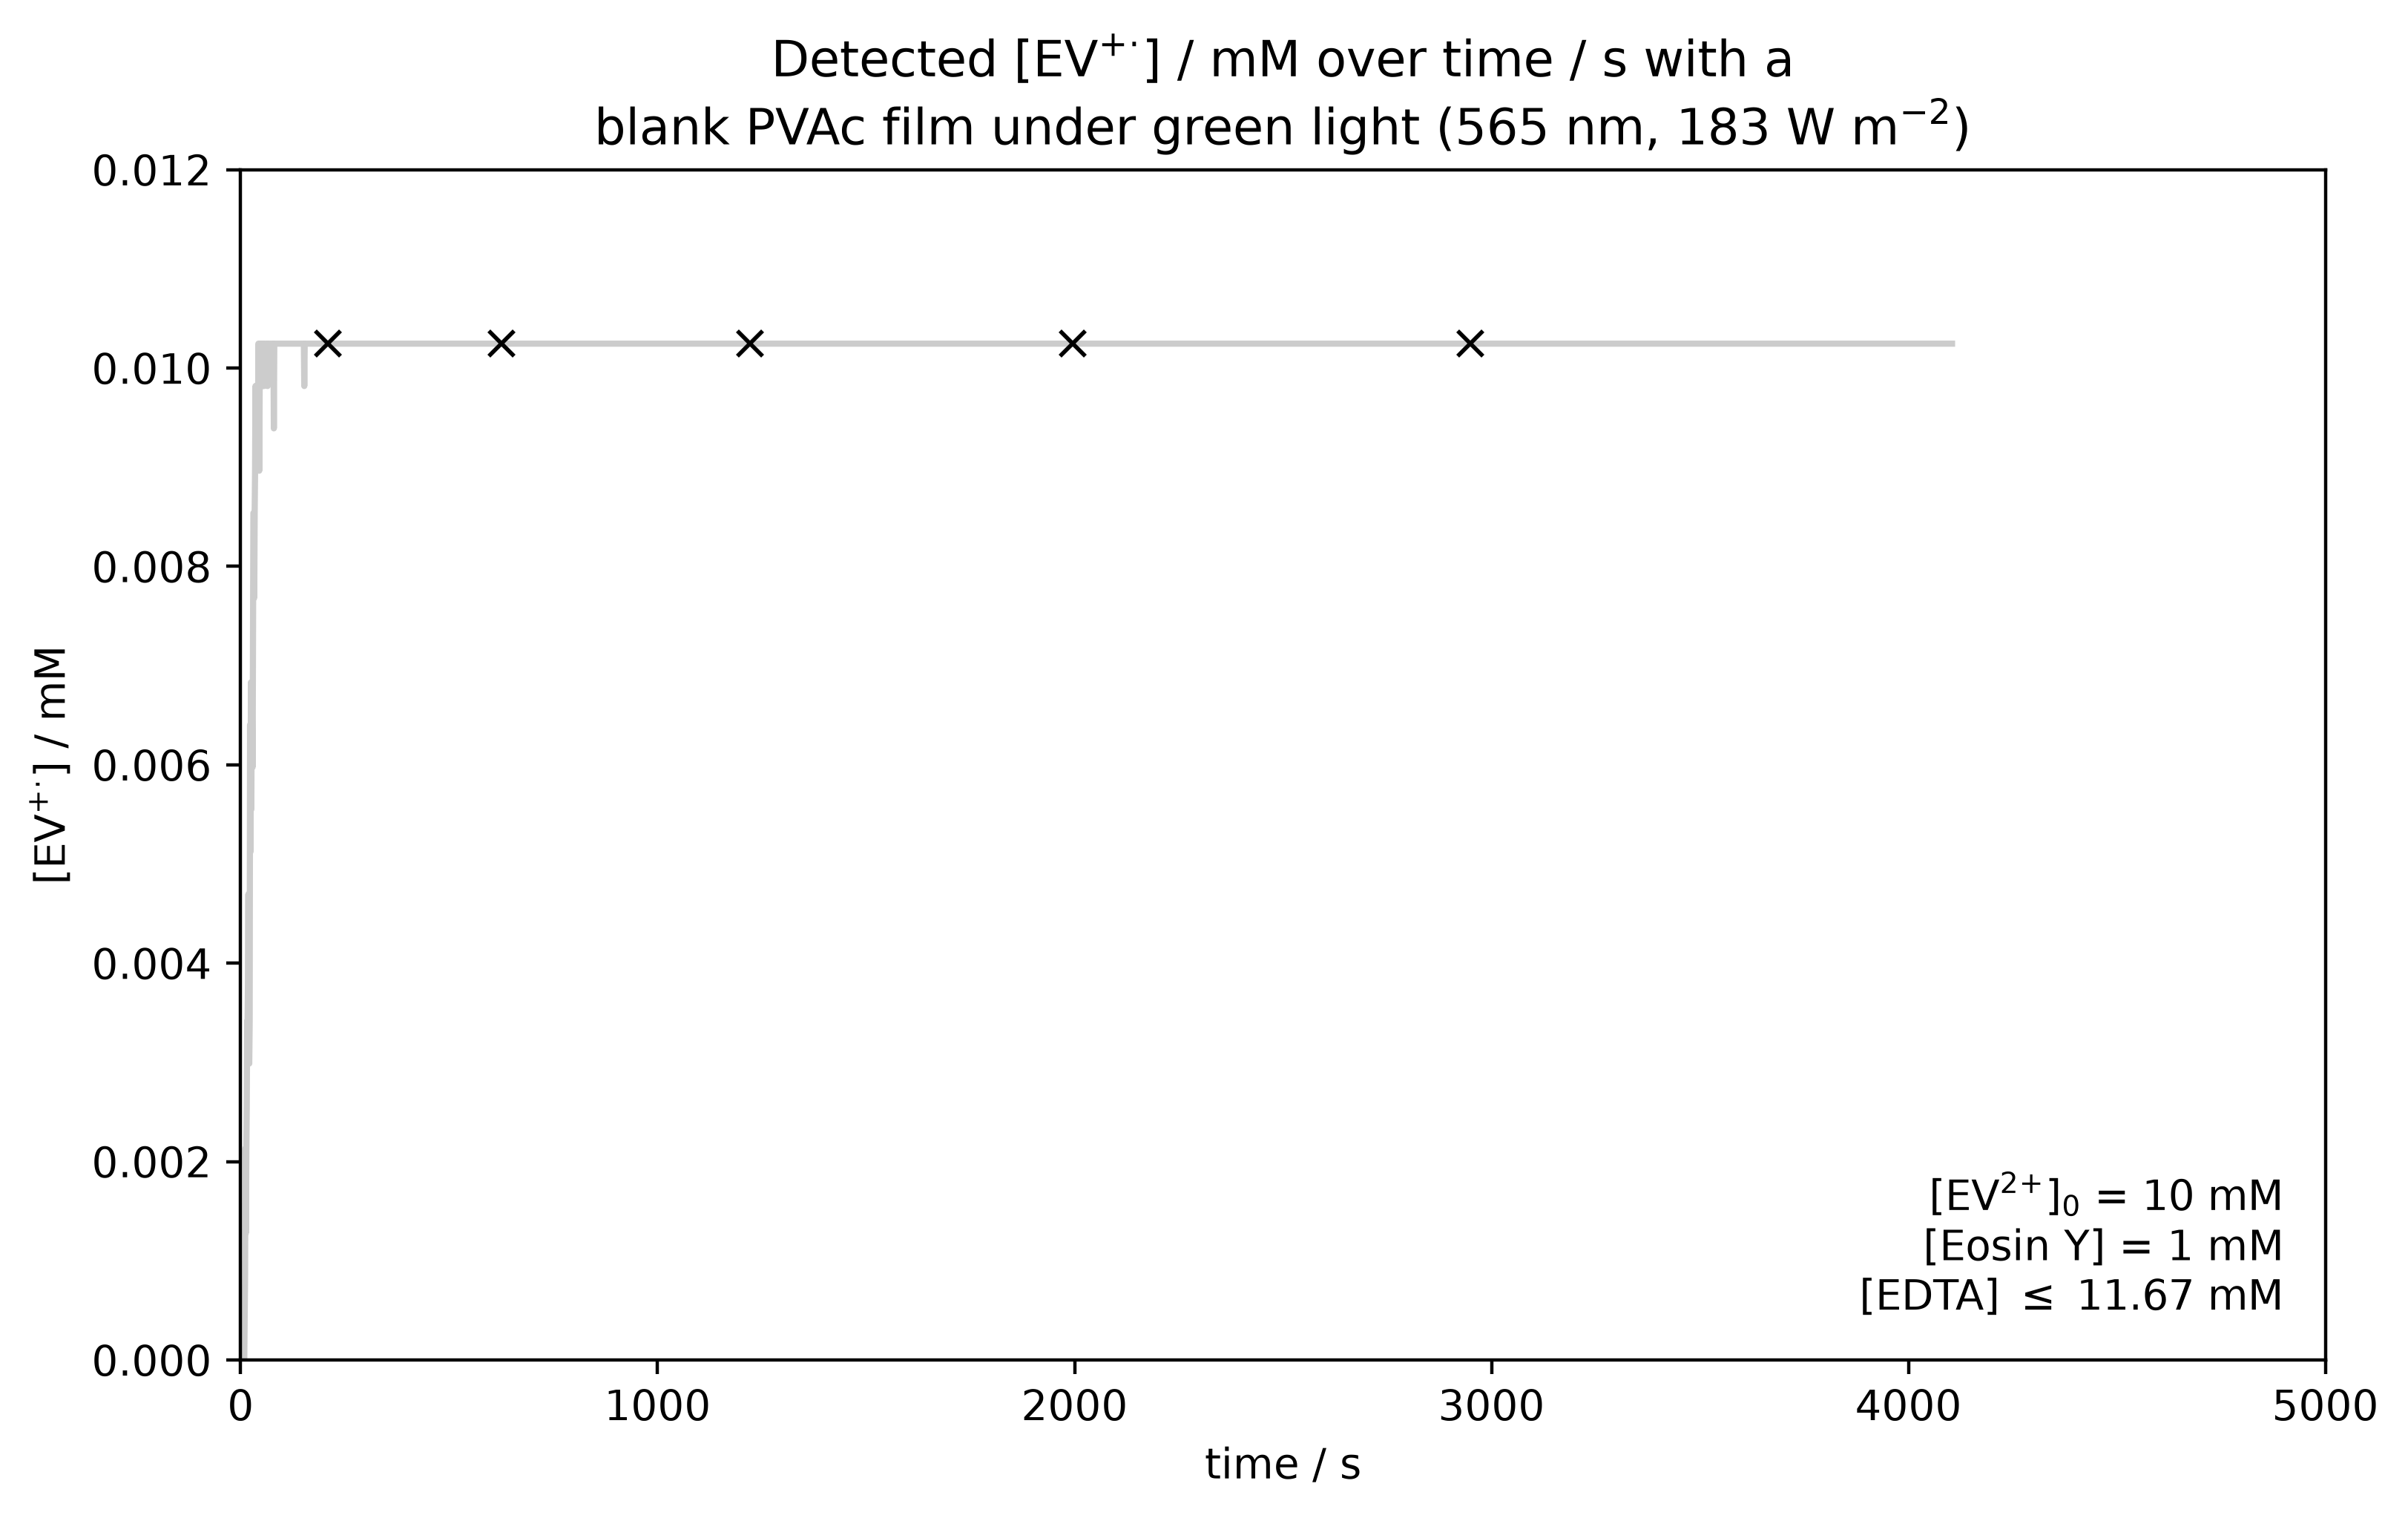

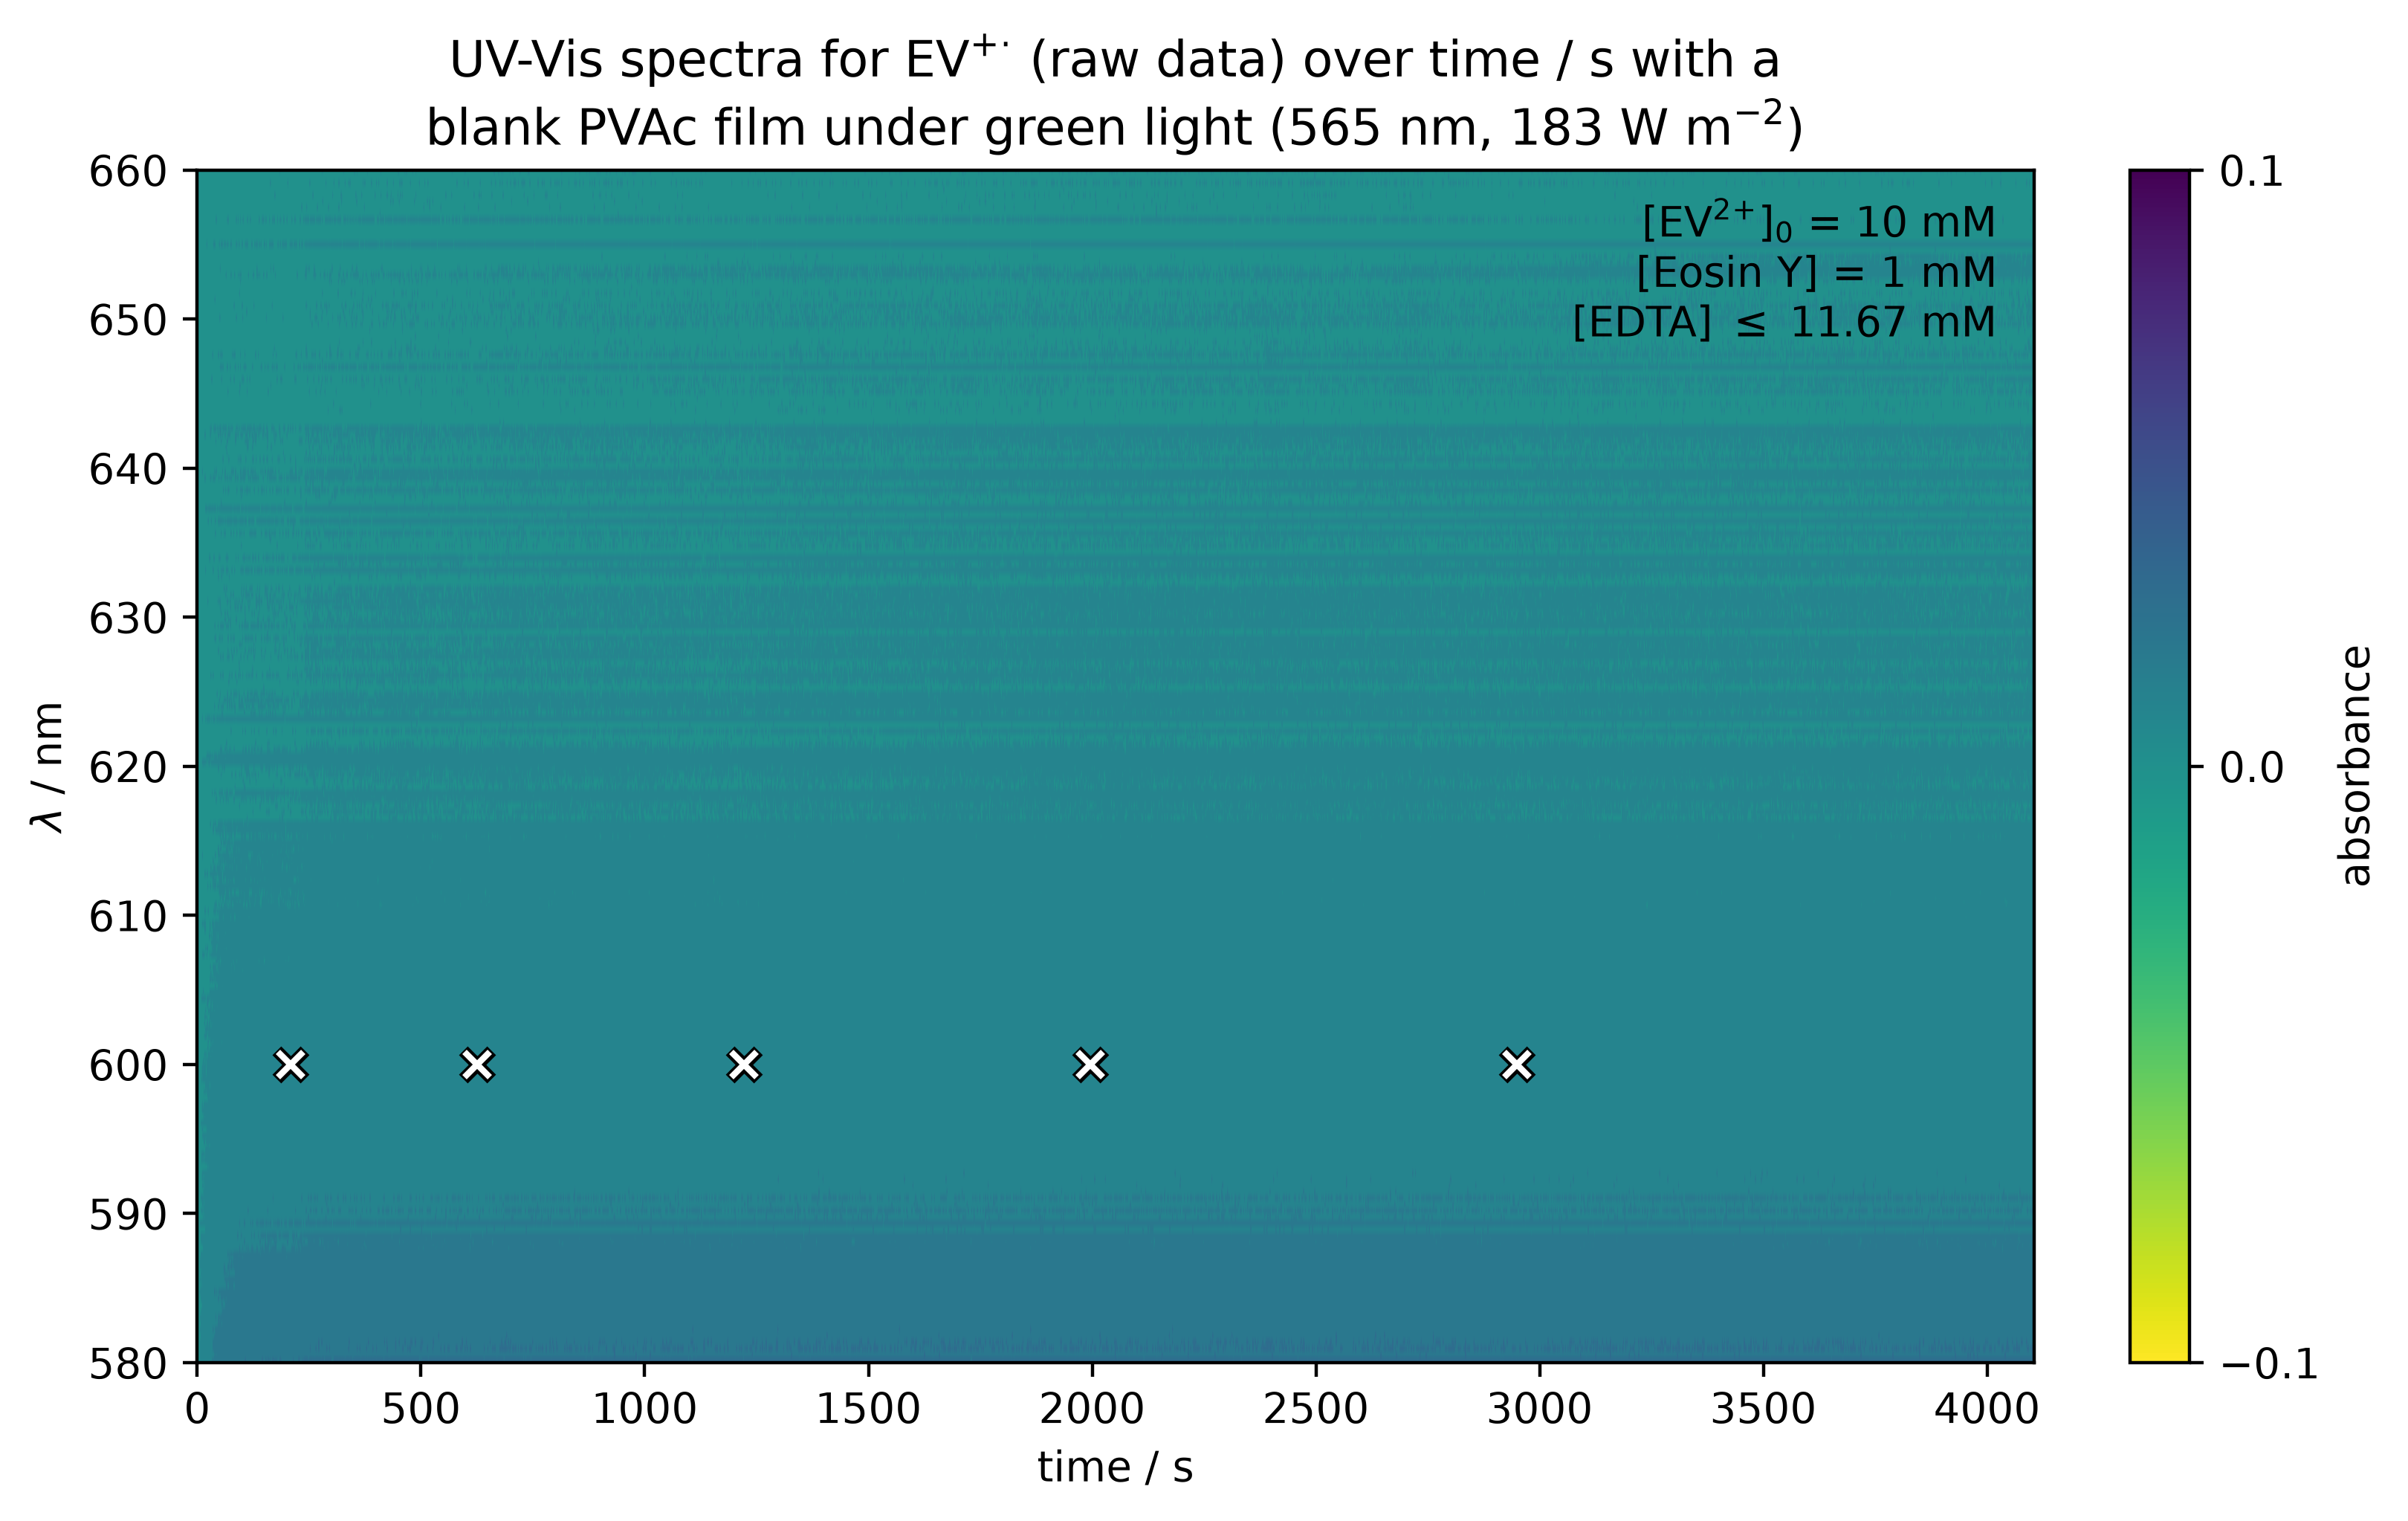

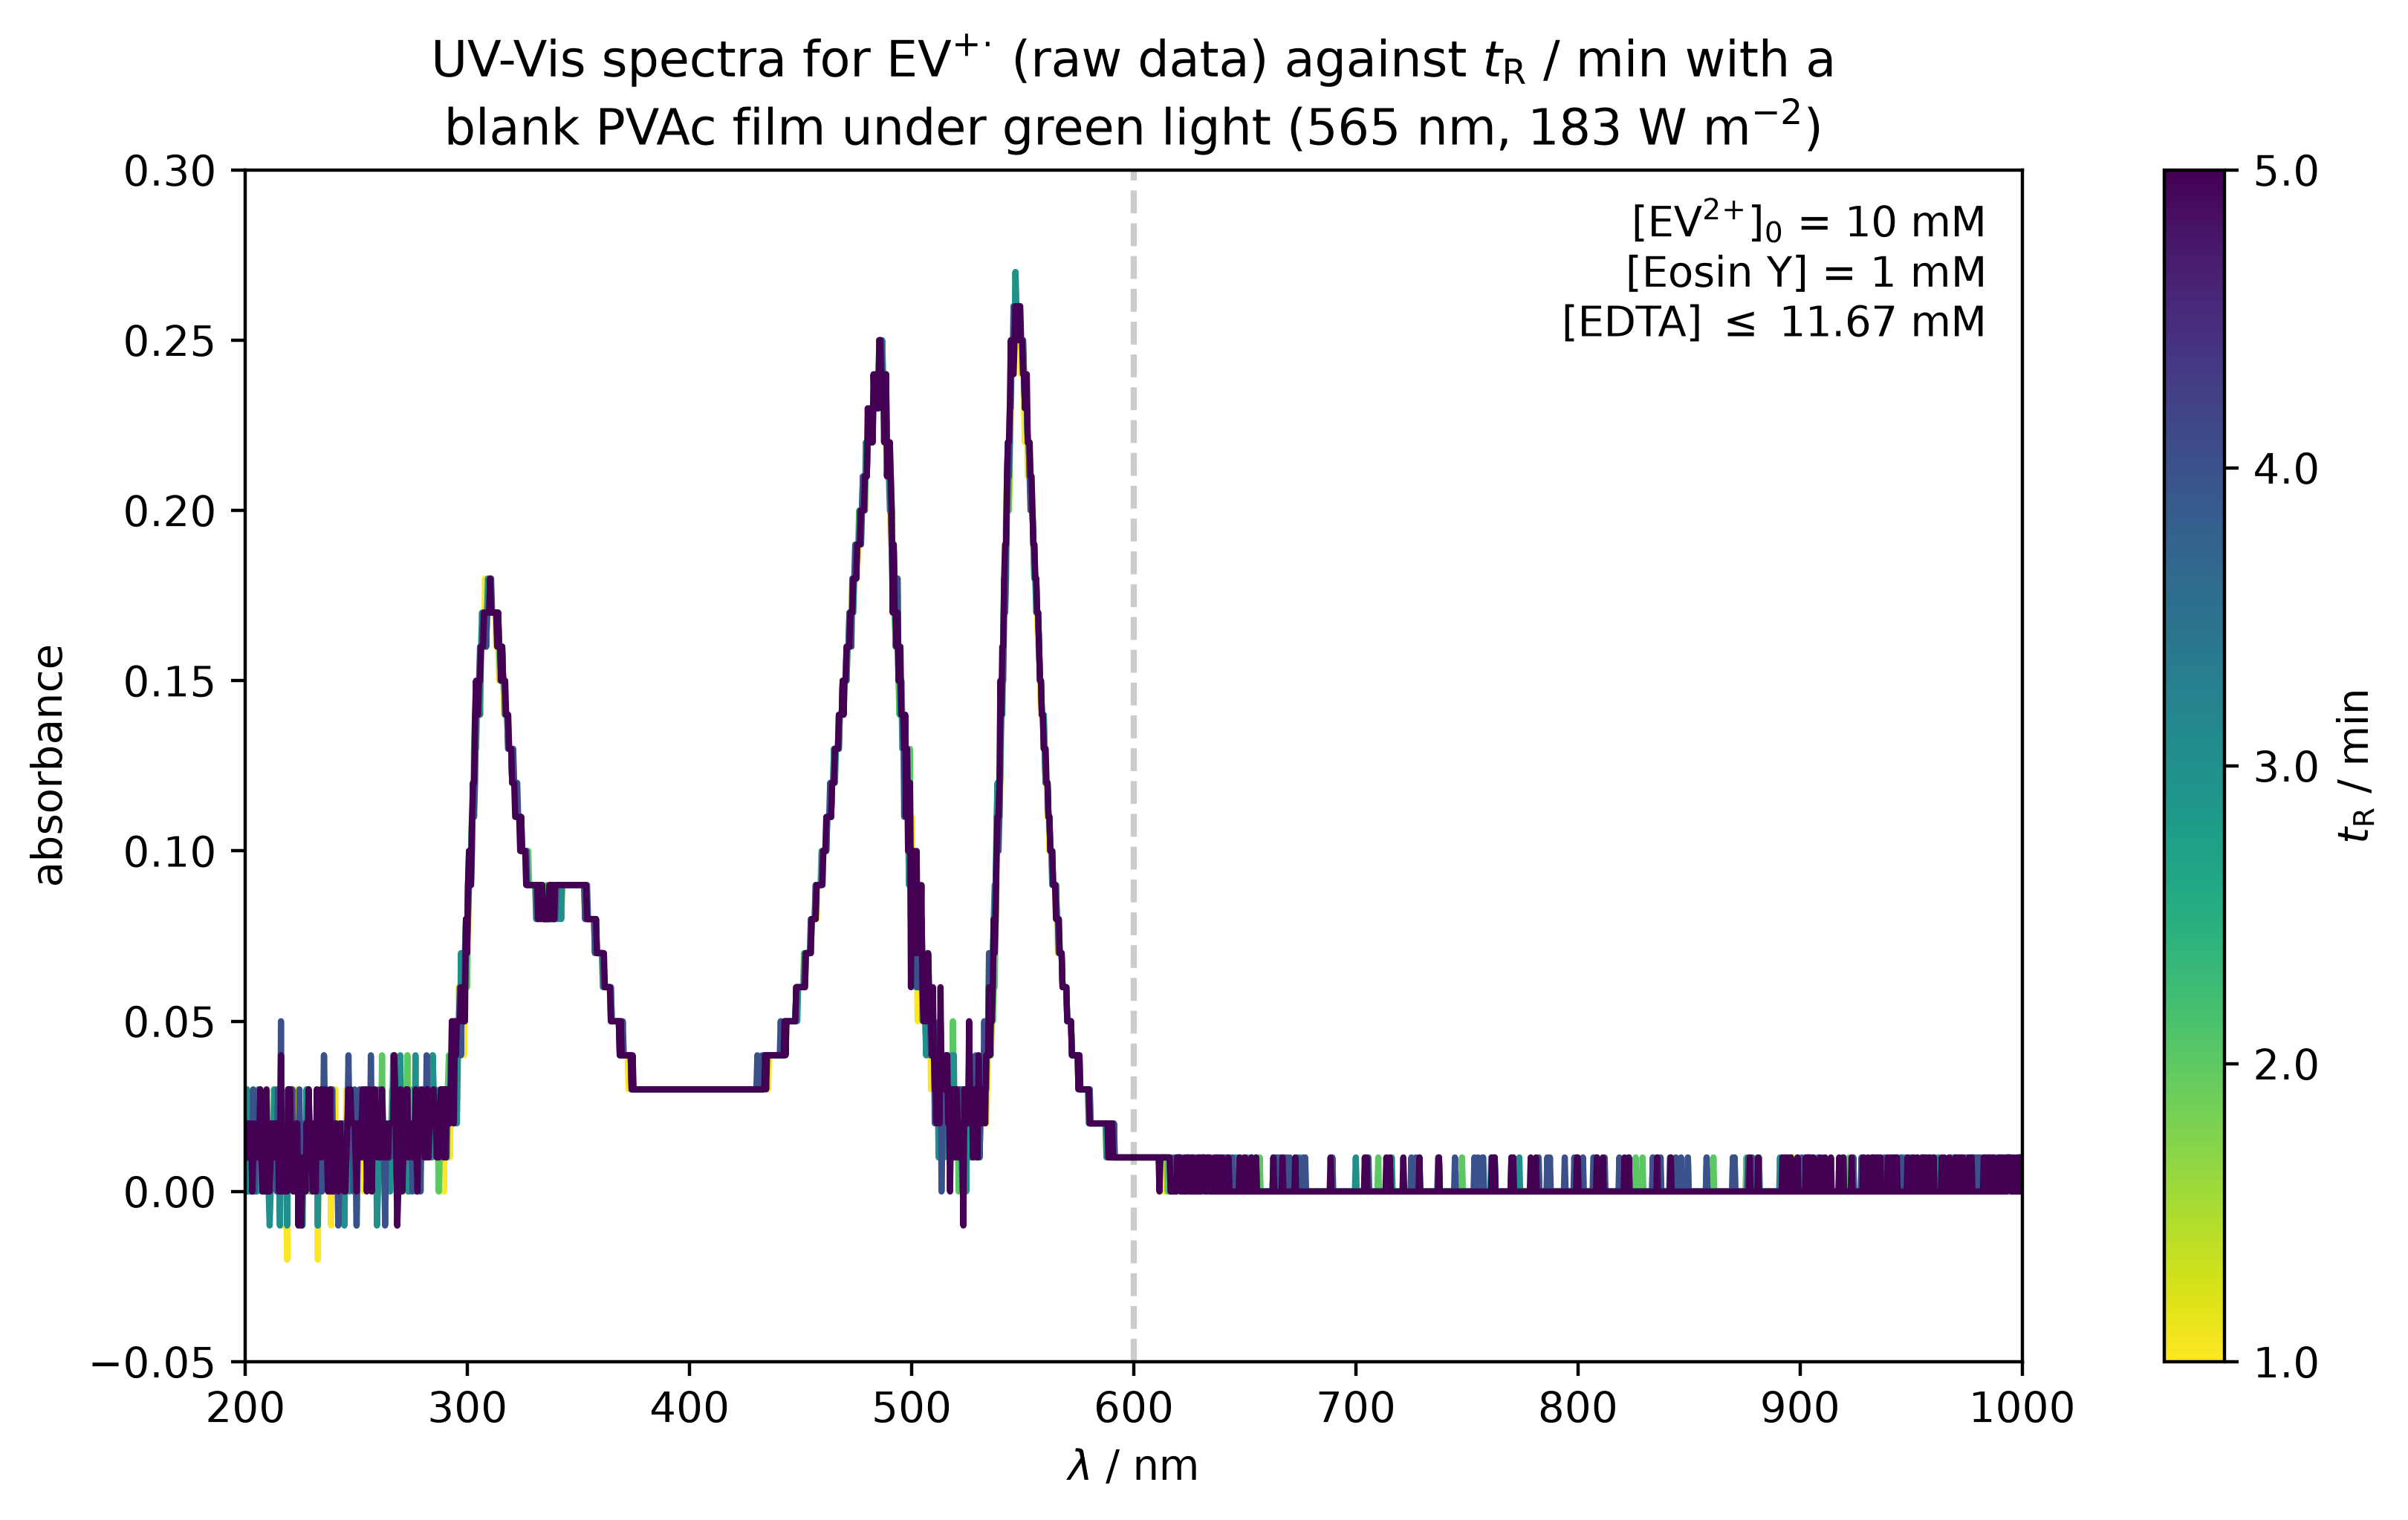

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Green 565 nm irradiation at 13.0 mW.

Eosin Y EDTA trial 2 in flow.
- Higher mol% Eosin Y.
- Took inital reaction solution as UV-Vis background but fluorescence messed up the peak.

V(Eosin Y, 5 mM, pH 7 buffer) = 600 ul (1 mM),
V(EV2+, 30 mM, pH 7 buffer) = 1000 ul (10 mM),
V(EDTA, saturated <25 mM, pH 7 buffer) = 1400 ul (<11.67 mM).
"""

data = '260731_EosinY_EV_EDTA_Blank_Green_Flow_2' # data folder name

tRs = np.arange(60, 5*60+1, 60) # residence times/s for 1-5 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
start = "12-22-00-000" # recorded start time

c0 = 10e-3 # initial EV2+ concentration
details = '[Eosin Y] = 1 mM\n[EDTA] $\\leq$ 11.67 mM' # concentrations of other reagents

x = 'EVxanthenegreen'
film = 'blank PVAc'
light = 'green'
wavelength = 565e-9 # m
power = 13.0e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power, correction=False)
expt.concvstimeplot()
expt.concvstimeplot(ln=True)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()